In [140]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from data import *
from metrics import *
from scipy import ndimage

In [141]:
x, y = get_stanford_background()

In [142]:
x = cv2.imread(x[3])
y = cv2.imread(y[3], cv2.IMREAD_GRAYSCALE)

Text(0.5, 1.0, 'ground truth')

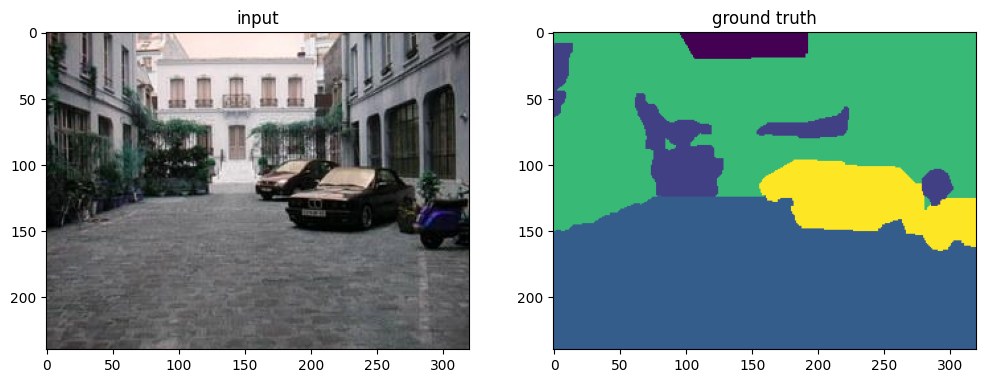

In [143]:
plt.figure(figsize=(12, 10))

plt.subplot(1, 2, 1)
plt.imshow(x)
plt.title('input')

plt.subplot(1, 2, 2)
plt.imshow(y)
plt.title('ground truth')

In [144]:
from segment_anything import sam_model_registry, SamPredictor

device = 'cuda:2'
sam_checkpoint = "./checkpoints/sam_vit_h_4b8939.pth"
model_type = "vit_h"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)
sam.eval()

predictor = SamPredictor(sam)

In [145]:
predictor.set_image(x)

In [146]:
def get_box_prompts(mask, expand_ratio=0.02):
    
    H, W = mask.shape
    expand_x = int(W * expand_ratio)
    expand_y = int(H * expand_ratio)

    boxes = []

    classes = np.unique(mask)

    for cls in classes:
        if cls:
            binary = (mask == cls).astype(np.uint8)

            num_labels, labels = cv2.connectedComponents(binary)

            for i in range(1, num_labels):
                component = (labels == i).astype(np.uint8)

                ys, xs = np.where(component)

                if len(xs) == 0:
                    continue

                x1, x2 = xs.min(), xs.max()
                y1, y2 = ys.min(), ys.max()

                x1 = max(0, x1 - expand_x)
                y1 = max(0, y1 - expand_y)
                x2 = min(W - 1, x2 + expand_x)
                y2 = min(H - 1, y2 + expand_y)

                boxes.append([x1, y1, x2, y2])

    return boxes

def get_point_prompts(mask):
    labeled_mask, num_regions = ndimage.label(mask == 1)
    points = []
    for region_id in range(1, num_regions + 1):
        region = labeled_mask == region_id
        dist = ndimage.distance_transform_edt(region)
        cy, cx = np.unravel_index(np.argmax(dist), dist.shape)
        points.append([cx, cy])

    return np.array(points)

def split_masks(y):
    masks = []

    ids = np.unique(y)

    for gid in ids:
        masks.append(y == gid)

    return masks

def sam_predict_mask(predictor, image, prompts, prompt_type):

    if prompt_type == 'point':
        labels = np.ones(len(prompts))
        masks, scores, _ = predictor.predict(
            point_coords=prompts,
            point_labels=labels,
            multimask_output=False
        )
        return masks[0]

    elif prompt_type == 'box':
        final_mask = None

        for box in prompts:
            box = np.array(box)
            masks, scores, _ = predictor.predict(
                box=box,
                multimask_output=False
            )

            pred = masks[0]

            if final_mask is None:
                final_mask = pred
            else:
                final_mask = np.logical_or(final_mask, pred)

        return final_mask



def evaluate_sam(image, gt_mask, predictor, prompt_type):

    masks = split_masks(gt_mask)

    ious = []
    dices = []
    precisions = []
    recalls = []

    preds = []

    predictor.set_image(image)

    for mask in masks:

        if prompt_type == 'point':
            points = get_point_prompts(mask)
            pred = sam_predict_mask(predictor, image, points, prompt_type)

        elif prompt_type == 'box':
            boxes = get_box_prompts(mask)
            pred = sam_predict_mask(predictor, image, boxes, prompt_type)

        preds.append(pred)

        metrics = compute_metrics(pred, mask)

        ious.append(metrics["iou"])
        dices.append(metrics["dice"])
        precisions.append(metrics["precision"])
        recalls.append(metrics["recall"])

    mean_metrics = {
        "miou": np.round(np.mean(ious), 2),
        "mdice": np.round(np.mean(dices), 2),
        "mprecision": np.round(np.mean(precisions), 2),
        "mrecall": np.round(np.mean(recalls), 2)
    }

    return mean_metrics, preds, masks


In [147]:
metrics, preds, masks = evaluate_sam(x, y, predictor, 'box')

In [148]:
metrics

{'miou': np.float64(0.84),
 'mdice': np.float64(0.9),
 'mprecision': np.float64(0.97),
 'mrecall': np.float64(0.86)}

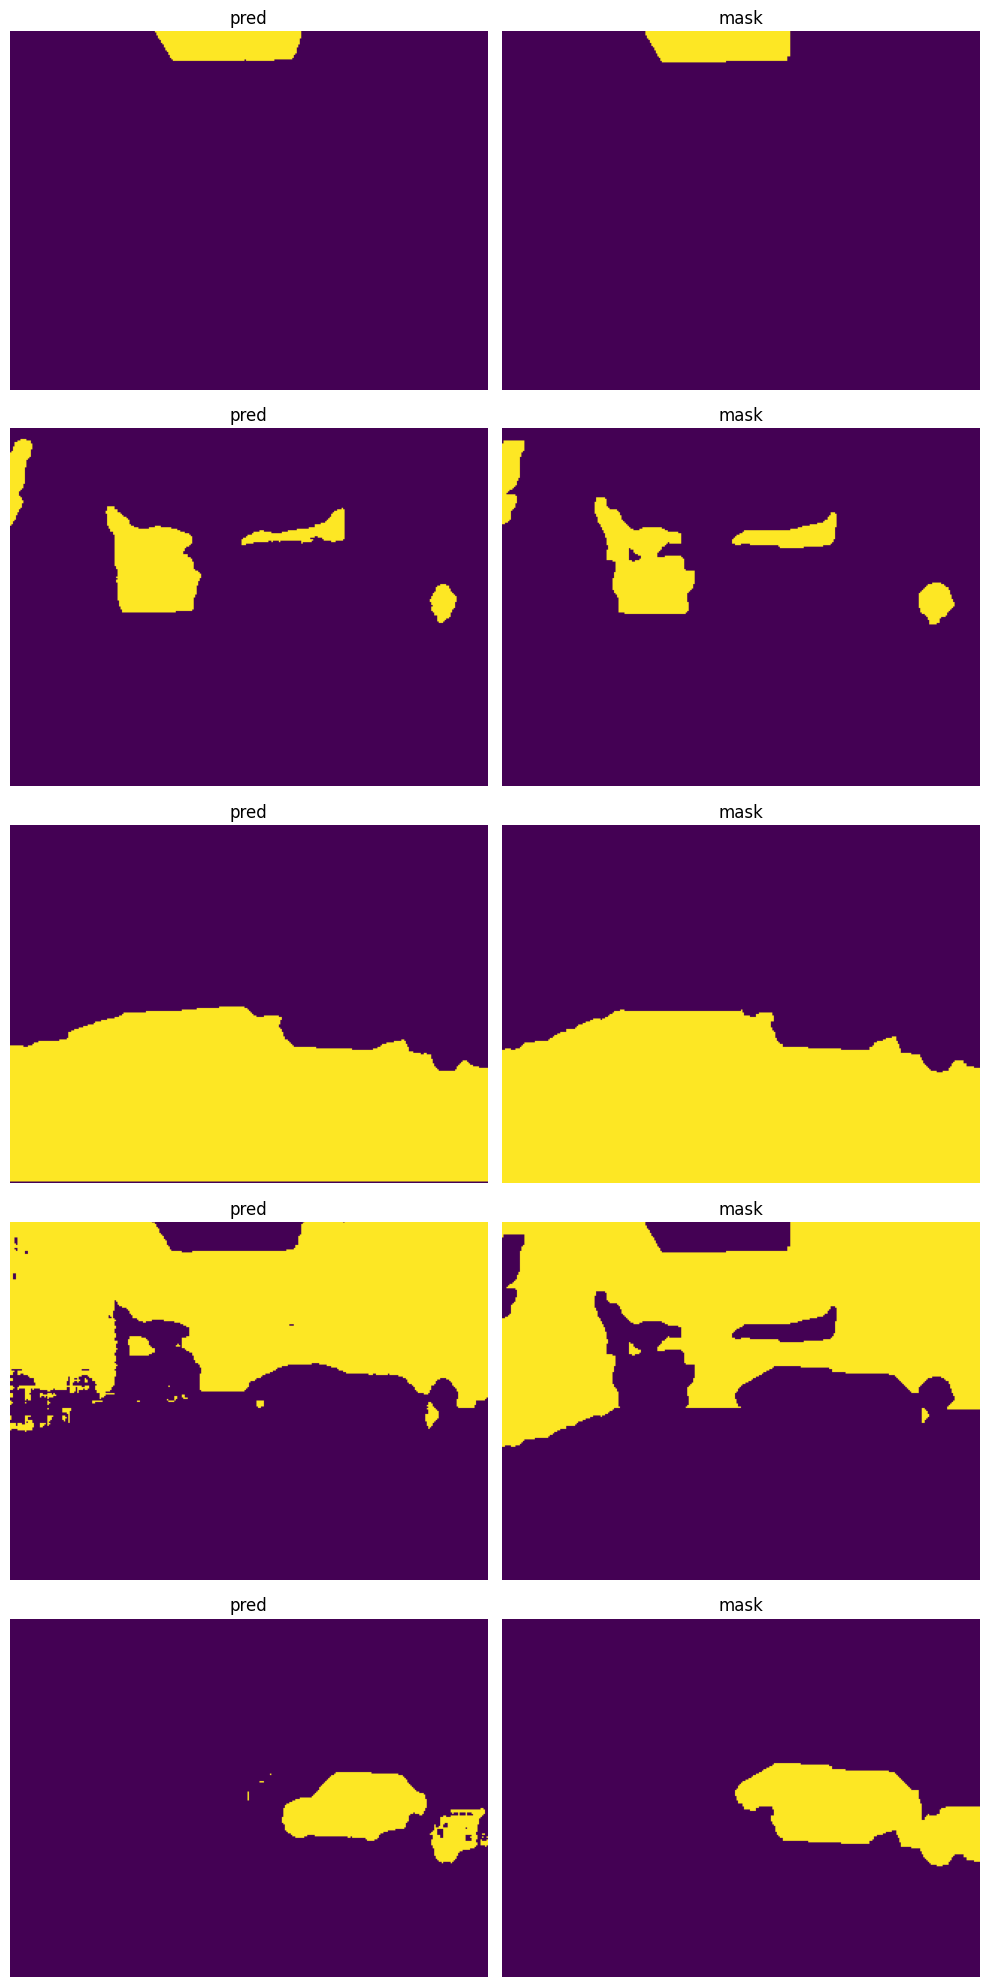

In [149]:
n = len(masks)

plt.figure(figsize=(10, 4 * n))

for i in range(n):
    plt.subplot(n, 2, 2*i + 1)
    plt.imshow(preds[i])
    plt.axis("off")
    plt.title("pred")

    plt.subplot(n, 2, 2*i + 2)
    plt.imshow(masks[i])
    plt.axis("off")
    plt.title("mask")

plt.tight_layout()
plt.show()

In [150]:
def plot_one_sample(image, preds, mask, prompt_type):

    plt.figure(figsize=(10, 4 * n))
    for i in range(n):

        plt.subplot(n, 2, 2*i + 1)
        plt.imshow(x)

        if prompt_type == "point":
            pts = get_point_prompts(masks[i])
            plt.scatter(pts[:,0], pts[:,1], c="red", s=70, marker='*')

        elif prompt_type == "box":
            boxes = get_box_prompts(masks[i])
            for b in boxes:
                x1, y1, x2, y2 = b
                w = x2 - x1
                h = y2 - y1
                rect = plt.Rectangle((x1, y1), w, h,
                                    edgecolor="red",
                                    facecolor="none",
                                    linewidth=2)
                plt.gca().add_patch(rect)

        plt.imshow(preds[i], alpha=0.5)
        plt.axis("off")
        plt.title("pred + prompt")

        plt.subplot(n, 2, 2*i + 2)
        plt.imshow(masks[i])
        plt.axis("off")
        plt.title("mask")

    plt.tight_layout()
    plt.show()

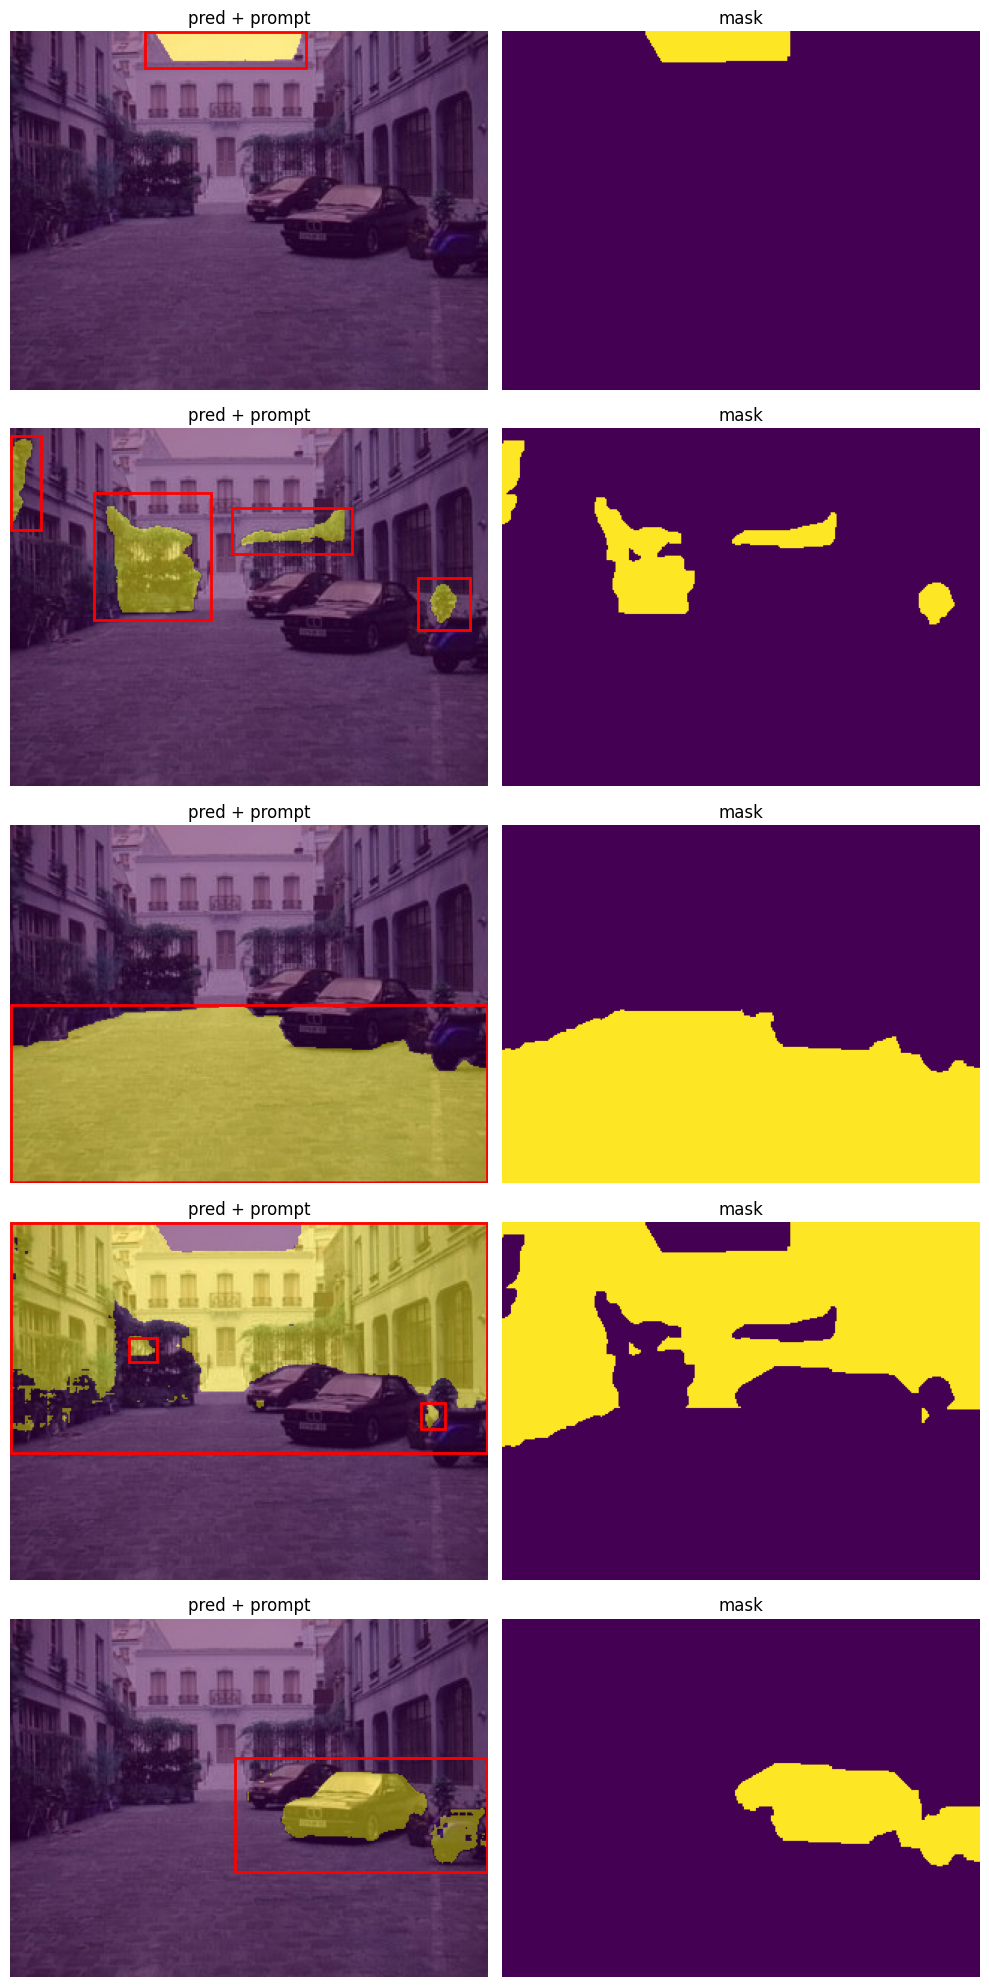

In [151]:
plot_one_sample(x, preds, y, 'box')

In [152]:
metrics, preds, masks = evaluate_sam(x, y, predictor, 'point')

In [153]:
metrics

{'miou': np.float64(0.6),
 'mdice': np.float64(0.7),
 'mprecision': np.float64(0.81),
 'mrecall': np.float64(0.77)}

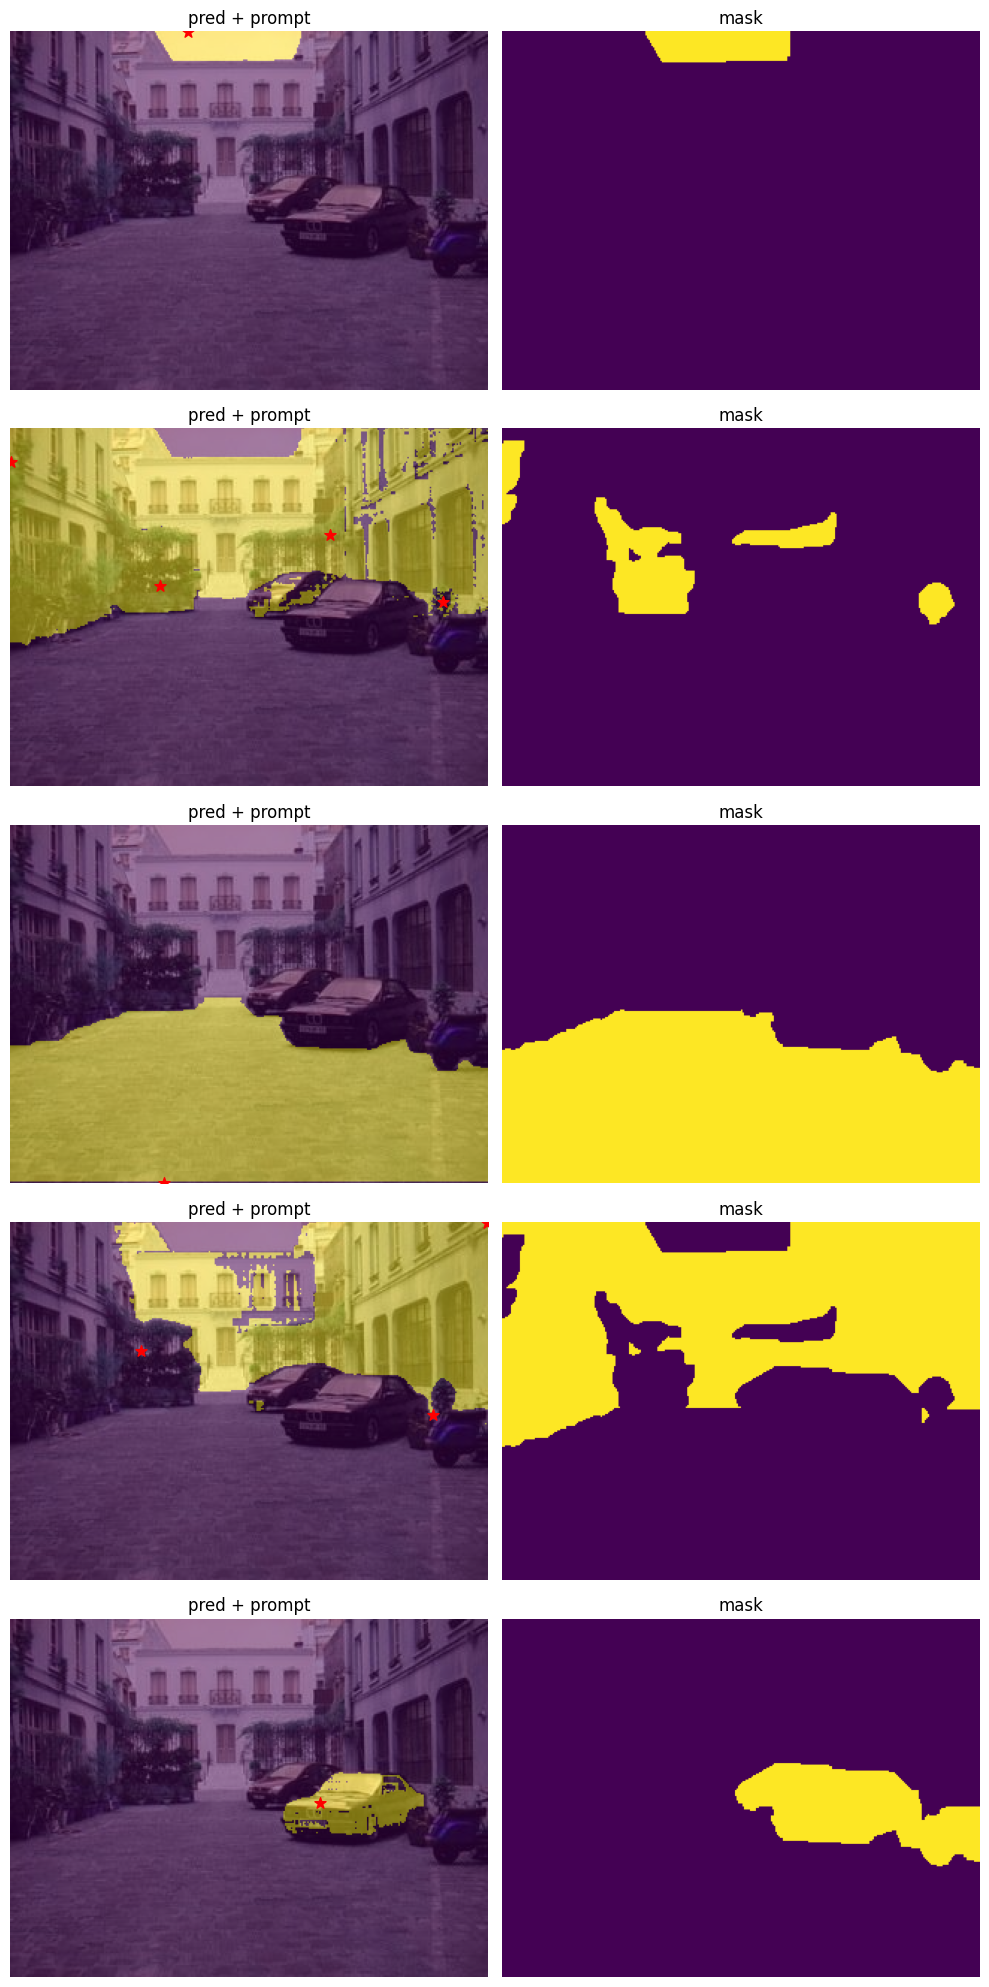

In [154]:
plot_one_sample(x, preds, y, 'point')